### Lab 8: Decision Trees
8.3.1 Fitting Classification Trees

BASE TREE PERFORMANCE
Number of terminal nodes: 33
Test Accuracy (Unpruned): 0.7350

CROSS-VALIDATION RESULTS
Best ccp_alpha found: 0.000000

PRUNED TREE PERFORMANCE
Number of terminal nodes: 33
Test Accuracy (Pruned)  : 0.7350

Confusion Matrix:
          Pred No  Pred Yes
True No        94        32
True Yes       21        53


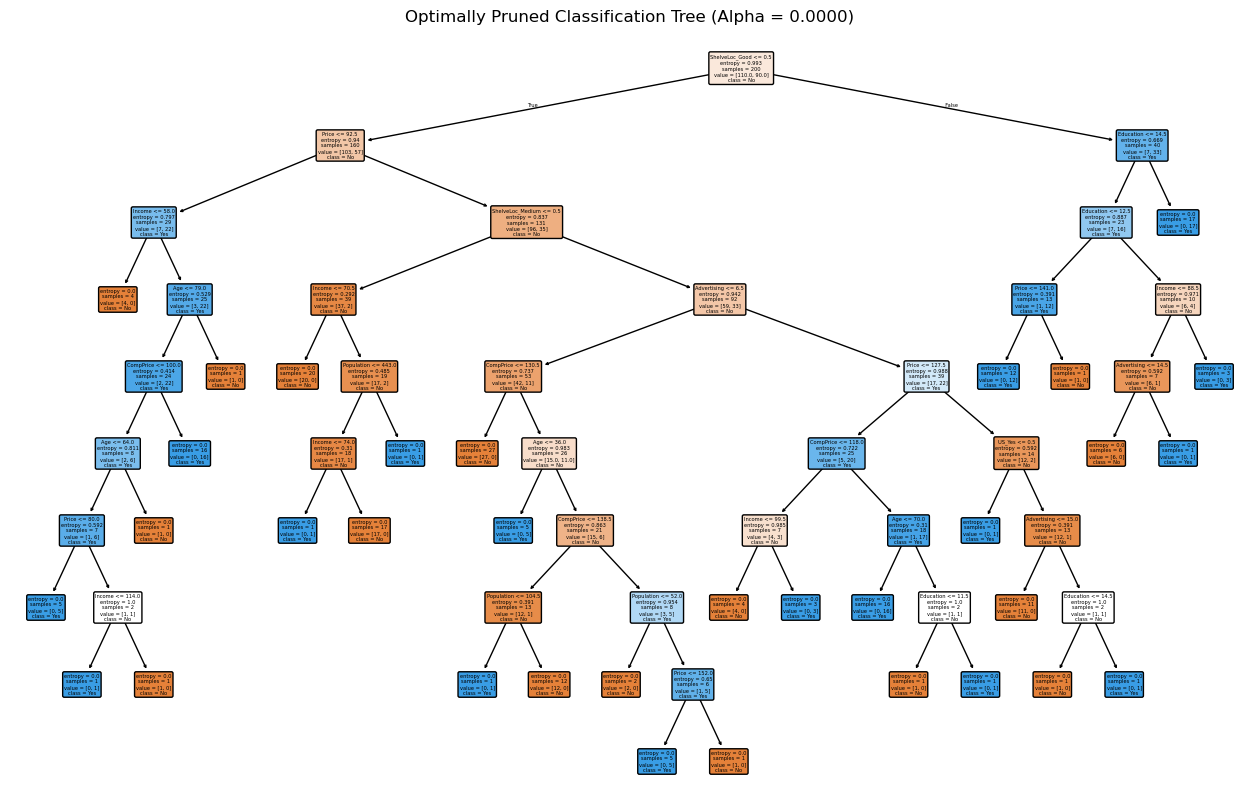

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
import statsmodels.api as sm
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score


# 1. Load data
carseats = pd.read_csv("data/Carseats.csv")

# Создаем бинарный целевой признак High (Sales > 8)
carseats["High"] = np.where(carseats["Sales"] > 8, "Yes", "No")

# Remove Sales variable
X = carseats.drop(columns=["Sales", "High"])
y = carseats["High"]

# Coding categorical features (ShelveLoc, Urban, US) One-Hot Encoding
X = pd.get_dummies(X, columns=["ShelveLoc", "Urban", "US"], drop_first=True)

# 2. Dividing train test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=200, random_state=2)

# 3. Fit base model
base_tree = DecisionTreeClassifier(criterion="entropy", random_state=42)
base_tree.fit(X_train, y_train)

# Estimating base model
y_pred_base = base_tree.predict(X_test)
base_acc = accuracy_score(y_test, y_pred_base)
print("BASE TREE PERFORMANCE")
print(f"Number of terminal nodes: {base_tree.get_n_leaves()}")
print(f"Test Accuracy (Unpruned): {base_acc:.4f}\n")

# 4. Pruning (Cost Complexity Pruning)
path = base_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Selecting best ccp_alpha
kf = KFold(n_splits=5, shuffle=True, random_state=3)
alpha_scores = []

for alpha in ccp_alphas:
    fold_accuracies = []
    for train_idx, val_idx in kf.split(X_train):
        clf = DecisionTreeClassifier(criterion="entropy", ccp_alpha=alpha, random_state=42)
        clf.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        
        val_pred = clf.predict(X_train.iloc[val_idx])
        fold_accuracies.append(accuracy_score(y_train.iloc[val_idx], val_pred))
        
    alpha_scores.append(np.mean(fold_accuracies))

best_alpha = ccp_alphas[np.argmax(alpha_scores)]
print("CROSS-VALIDATION RESULTS")
print(f"Best ccp_alpha found: {best_alpha:.6f}")

# 5. Final pruning using best alpha
pruned_tree = DecisionTreeClassifier(criterion="entropy", ccp_alpha=best_alpha, random_state=42)
pruned_tree.fit(X_train, y_train)

# Estimating the model
y_pred_pruned = pruned_tree.predict(X_test)
pruned_acc = accuracy_score(y_test, y_pred_pruned)

print("\nPRUNED TREE PERFORMANCE")
print(f"Number of terminal nodes: {pruned_tree.get_n_leaves()}")
print(f"Test Accuracy (Pruned)  : {pruned_acc:.4f}")
print("\nConfusion Matrix:")
print(pd.DataFrame(confusion_matrix(y_test, y_pred_pruned), 
                   index=["True No", "True Yes"], 
                   columns=["Pred No", "Pred Yes"]))

plt.figure(figsize=(16, 10))
plot_tree(pruned_tree, feature_names=X.columns, class_names=["No", "Yes"], filled=True, rounded=True)
plt.title(f"Optimally Pruned Classification Tree (Alpha = {best_alpha:.4f})")
plt.show()

Interestingly, the 5-fold cross-validation procedure selected an optimal complexity parameter of ccp_alpha = 0.000000. Consequently, the pruning algorithm did not eliminate any branches, leaving the final tree identical to the initial unpruned model with 33 terminal nodes and a test accuracy of 73.50%. This indicates that on this specific split of the training data, the added complexity of the deeper subtrees was justified by a genuine reduction in empirical risk during cross-validation, meaning no complexity penalty was enforced

Analyzing the test set performance via the confusion matrix yields a Recall of 71.62% ($53/74$) and a Precision of 62.35% ($53/85$). These results present a trade-off in model behavior:
- High Recall (71.62%) demonstrates that the model is quite aggressive and effective at identifying high-performing stores, successfully capturing nearly 72% of the true positive instances.
- Lower Precision (62.35%) reveals that this boldness comes at a cost; the model suffers from a relatively high false-positive rate (32 instances), frequently misclassifying low-performing locations as high-performing ones

#### 8.3.2 Fitting Regression Trees

BASE REGRESSION TREE PERFORMANCE
Number of terminal nodes (leaves): 238
Train MSE: 0.0000
Test MSE (Unpruned): 18.5455

CROSS-VALIDATION RESULTS
Best ccp_alpha found: 0.300799

PRUNED REGRESSION TREE (5 LEAVES) PERFORMANCE
Number of terminal nodes: 5
Test MSE (Pruned): 27.2481



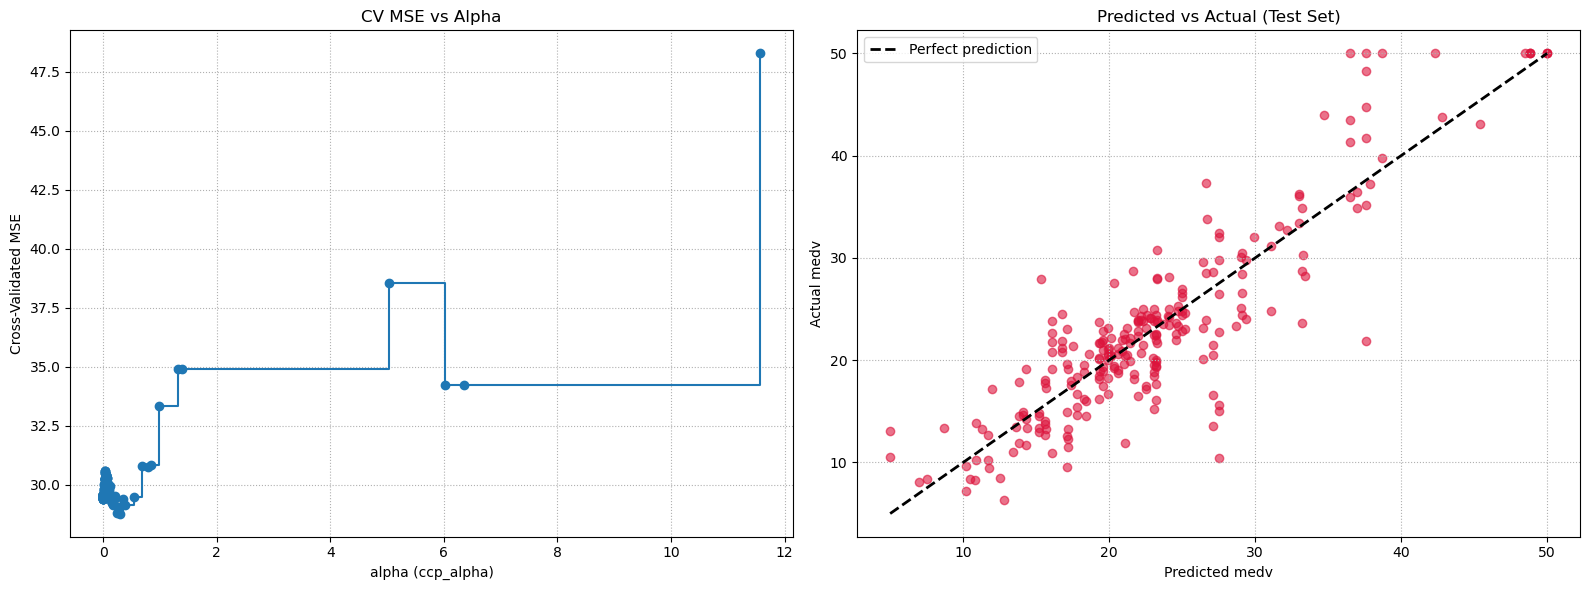

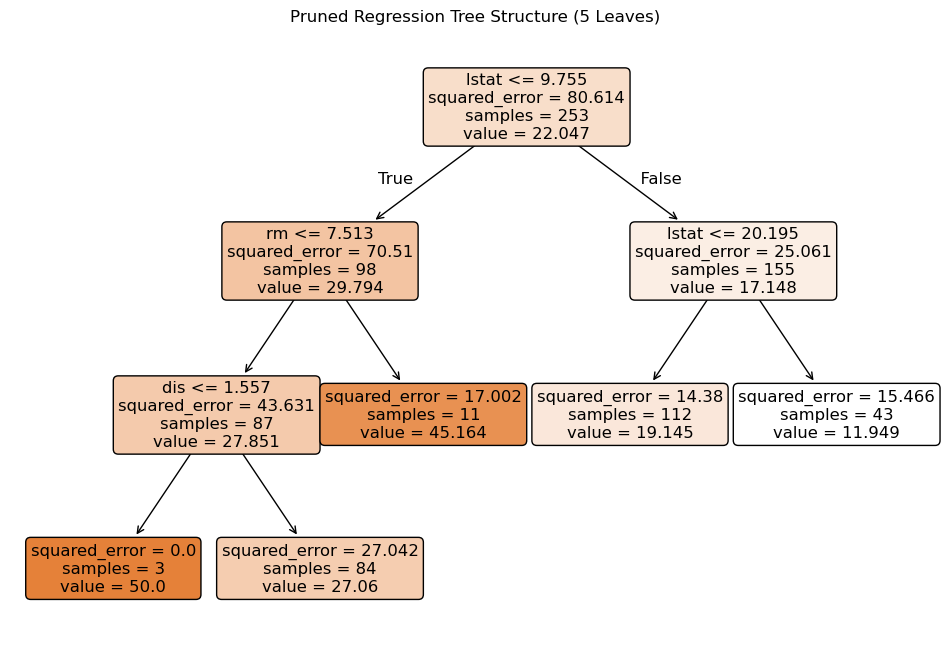

In [2]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# 1. Load data Boston
boston = pd.read_csv("data/Boston.csv")

X = boston.drop(columns=["medv"])
y = boston["medv"]

# 2. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

# 3. Fit base model
base_reg_tree = DecisionTreeRegressor(criterion="squared_error", random_state=42)
base_reg_tree.fit(X_train, y_train)

print("BASE REGRESSION TREE PERFORMANCE")
print(f"Number of terminal nodes (leaves): {base_reg_tree.get_n_leaves()}")
print(f"Train MSE: {mean_squared_error(y_train, base_reg_tree.predict(X_train)):.4f}")
print(f"Test MSE (Unpruned): {mean_squared_error(y_test, base_reg_tree.predict(X_test)):.4f}\n")

# 4. Select best alpha (Cost Complexity Pruning)
path = base_reg_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

kf = KFold(n_splits=5, shuffle=True, random_state=1)
alpha_mse_scores = []

for alpha in ccp_alphas:
    fold_mses = []
    for train_idx, val_idx in kf.split(X_train):
        clf = DecisionTreeRegressor(criterion="squared_error", ccp_alpha=alpha, random_state=42)
        clf.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        
        val_pred = clf.predict(X_train.iloc[val_idx])
        fold_mses.append(mean_squared_error(y_train.iloc[val_idx], val_pred))
        
    alpha_mse_scores.append(np.mean(fold_mses))

# best_alpha = ccp_alphas[np.argmin(alpha_scores)] if "alpha_scores" in locals() else ccp_alphas[np.argmin(alpha_mse_scores)]
best_alpha = ccp_alphas[np.argmin(alpha_mse_scores)]
print("CROSS-VALIDATION RESULTS")
print(f"Best ccp_alpha found: {best_alpha:.6f}")

# 5. Forced tree to prune
pruned_reg_tree = DecisionTreeRegressor(criterion="squared_error", max_leaf_nodes=5, random_state=42)
pruned_reg_tree.fit(X_train, y_train)

print("\nPRUNED REGRESSION TREE (5 LEAVES) PERFORMANCE")
print(f"Number of terminal nodes: {pruned_reg_tree.get_n_leaves()}")
print(f"Test MSE (Pruned): {mean_squared_error(y_test, pruned_reg_tree.predict(X_test)):.4f}\n")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].plot(ccp_alphas[:-1], alpha_mse_scores[:-1], marker='o', drawstyle="steps-post")
ax[0].set_xlabel("alpha (ccp_alpha)")
ax[0].set_ylabel("Cross-Validated MSE")
ax[0].set_title("CV MSE vs Alpha")
ax[0].grid(True, ls=":")

y_pred_test = base_reg_tree.predict(X_test)
ax[1].scatter(y_pred_test, y_test, alpha=0.6, color="crimson")
ax[1].plot([y.min(), y.max()], [y.min(), y.max()], "k--", lw=2, label="Perfect prediction")
ax[1].set_xlabel("Predicted medv")
ax[1].set_ylabel("Actual medv")
ax[1].set_title("Predicted vs Actual (Test Set)")
ax[1].legend()
ax[1].grid(True, ls=":")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plot_tree(pruned_reg_tree, feature_names=X.columns, filled=True, rounded=True)
plt.title("Pruned Regression Tree Structure (5 Leaves)")
plt.show()

The unpruned regression tree grew excessively deep, resulting in 238 terminal nodes, a Train MSE of 0.0000, and a Test MSE of 18.5455. This full tree represents a highly flexible model with high variance.

When we constrained the tree to only 5 terminal nodes, the Test MSE degraded to 27.2481. The reason for this poor performance is underfitting (high bias) rather than overfitting. By forcing such a strict limitation, we made the model too rigid, preventing it from capturing essential non-linear structures in the housing data

The 5-fold cross-validation path successfully identified an optimal tuning parameter of ccp_alpha = 0.300799. As shown in the left-hand cost-complexity chart, the validation error reaches its minimum at a relatively low alpha value before sharply rising as the penalty increases. This proves that while some regularization is required, pruning the model all the way down to 5 leaves introduces too much bias

The prediction scatter plot highlights that the unpruned model performs consistently across mid-range housing values but struggles significantly at the upper bound where Actual medv = 50, caused by the target variable's capping in the original dataset

Structurally, the features lstat (lower socioeconomic status percentage) and rm (average number of rooms) appear at the very top of the tree, confirming they are the most critical drivers of median home value

#### Task 8.3.3 Bagging and Random Forests

BAGGING PERFORMANCE (m=13)
Test MSE: 14.9766
Root MSE: 3.8700

RANDOM FOREST PERFORMANCE (m=6)
Test MSE: 13.3874
Root MSE: 3.6589



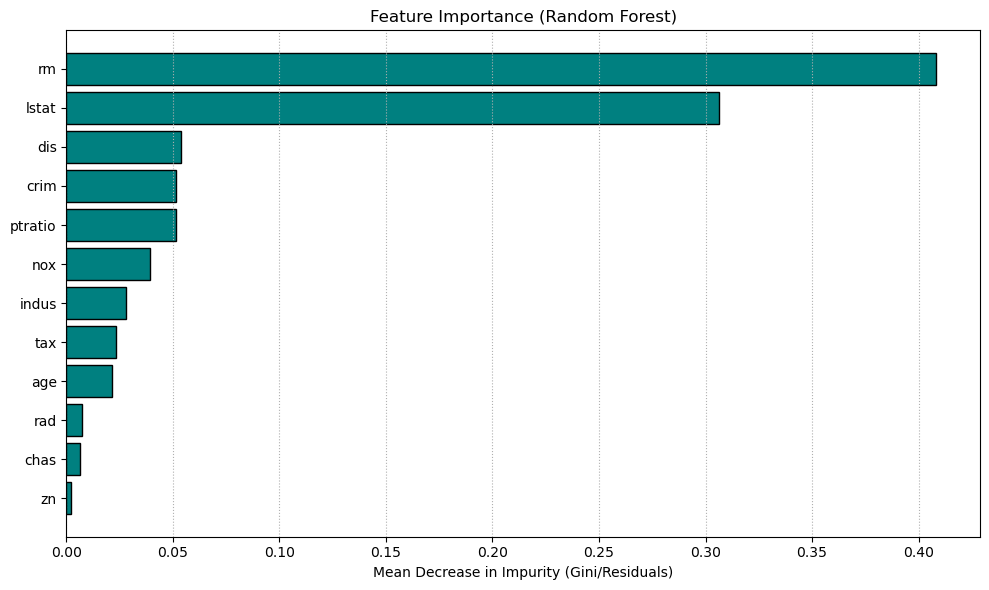

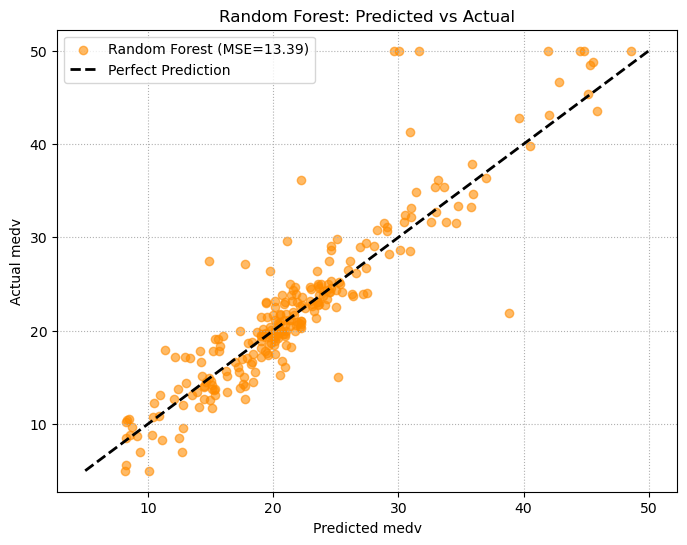

In [17]:
from sklearn.ensemble import RandomForestRegressor

# 1. Load data Boston
boston = pd.read_csv("data/Boston.csv")
boston.drop(columns=["Unnamed: 0"], axis=0, inplace=True)

X = boston.drop(columns=["medv"])
y = boston["medv"]

# 2. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# 3. BAGGING (m = p = 13)
bag_boston = RandomForestRegressor(n_estimators=500, max_features=13, random_state=42, n_jobs=-1)
bag_boston.fit(X_train, y_train)

y_pred_bag = bag_boston.predict(X_test)
bag_mse = mean_squared_error(y_test, y_pred_bag)

print("BAGGING PERFORMANCE (m=13)")
print(f"Test MSE: {bag_mse:.4f}")
print(f"Root MSE: {np.sqrt(bag_mse):.4f}\n")

# 4. RANDOM FOREST (m = 6)
rf_boston = RandomForestRegressor(n_estimators=500, max_features=6, random_state=42, n_jobs=-1)
rf_boston.fit(X_train, y_train)

y_pred_rf = rf_boston.predict(X_test)
rf_mse = mean_squared_error(y_test, y_pred_rf)

print("RANDOM FOREST PERFORMANCE (m=6)")
print(f"Test MSE: {rf_mse:.4f}")
print(f"Root MSE: {np.sqrt(rf_mse):.4f}\n")

# 5. VARIABLE IMPORTANCE
importances = rf_boston.feature_importances_
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="teal", edgecolor="k")
plt.xlabel("Mean Decrease in Impurity (Gini/Residuals)")
plt.title("Feature Importance (Random Forest)")
plt.grid(axis="x", ls=":")
plt.tight_layout()
plt.show()

# 6. Comparing models
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_rf, y_test, alpha=0.6, color="darkorange", label=f"Random Forest (MSE={rf_mse:.2f})")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "k--", lw=2, label="Perfect Prediction")
plt.xlabel("Predicted medv")
plt.ylabel("Actual medv")
plt.title("Random Forest: Predicted vs Actual")
plt.legend()
plt.grid(True, ls=":")
plt.show()

Both ensemble methods substantially outperform the single regression tree, cutting the test error nearly in half. In a direct comparison, the Random Forest approach ($m = 6$) outperformed Bagging ($m = 13$), achieving a lower Test MSE of 13.3874 compared to Bagging's 14.9766. This corresponds to a Root MSE of approximately 3.66, meaning the Random Forest predictions are, on average, within $\$3,660$ of the true median home values

The mathematical intuition behind Random Forest’s superiority lies in its ability to decorrelate individual trees. In Bagging, since all 13 predictors are evaluated at every split, strong dominant features like rm and lstat are consistently selected as top-level splitters across almost all bootstrapped trees. This high structural similarity leads to highly correlated tree predictions, which limits the ensemble's ability to minimize variance during averaging.


By restricting the available feature pool to $m = 6$, Random Forest forces many trees to split on alternative predictors (such as dis or crim), effectively uncovering alternative data interactions and further driving down the overall model variance